Building employee dataset …

════════════════════════════════════════════════════════════
  HR ANALYTICS & WORKFORCE INSIGHTS — FY 2024 REPORT
════════════════════════════════════════════════════════════

📊  KEY PERFORMANCE INDICATORS
  · Total Headcount           516
  · Attrition Rate %          12.8
  · Avg Salary ($K)           90.2
  · Avg Tenure (yrs)          2.85
  · YoY Growth Rate %         -12.2
  · Total Employees           592

👥  DEPARTMENT-WISE HEADCOUNT
  Engineering      139  ███████████████████████████
  Sales             95  ███████████████████
  Operations        89  █████████████████
  Marketing         65  █████████████
  Finance           52  ██████████
  Product           42  ████████
  HR                34  ██████

📉  ATTRITION ANALYSIS
  🟡 Engineering      10.9%
  🔴 Sales            20.2%
  🔴 Marketing        15.6%
  🟡 HR               10.5%
  🟢 Finance           3.7%
  🟡 Operations       12.7%
  🟢 Product           8.7%

💰  SALARY STATISTICS (active employees

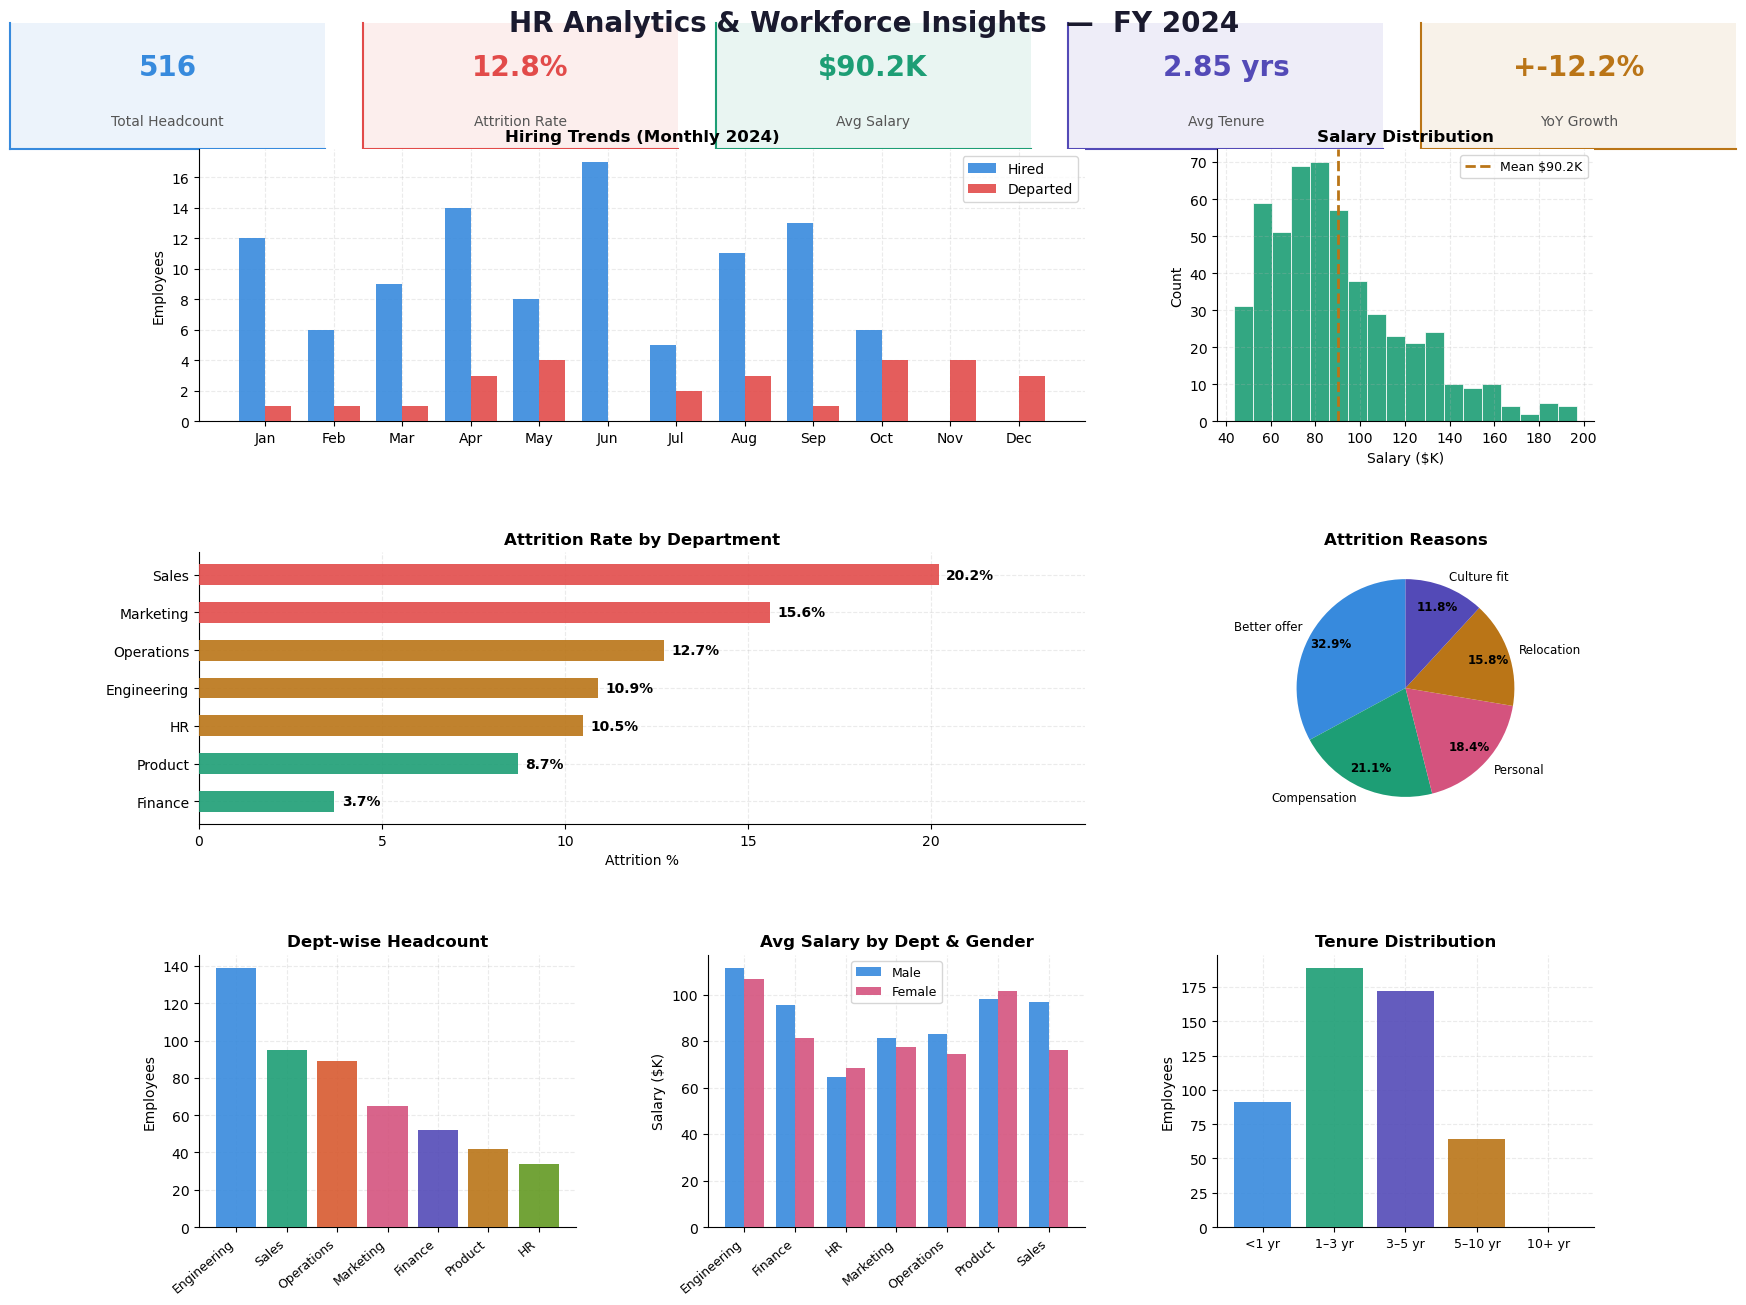

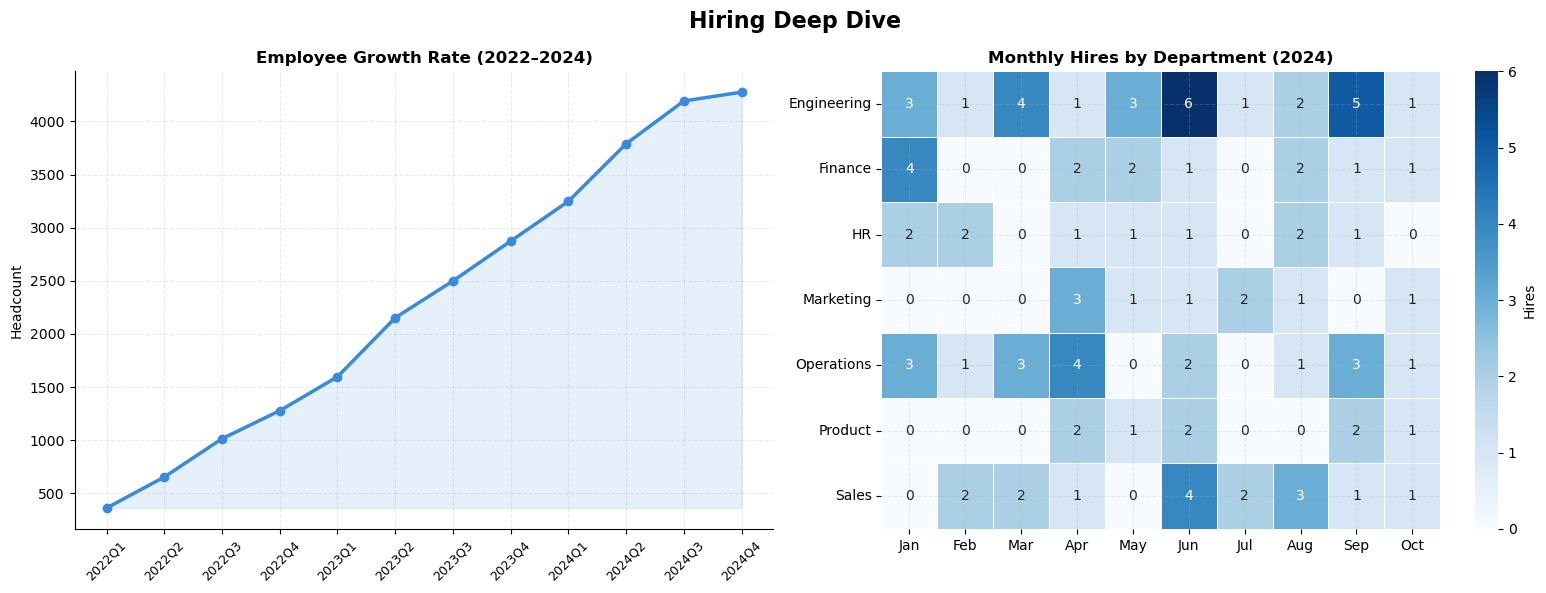

Exported → hr_employee_data.csv

All done! 🎉


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetic setup ────────────────────────────────────────────────────────────
PALETTE = {
    "blue":   "#378ADD",
    "green":  "#1D9E75",
    "coral":  "#D85A30",
    "pink":   "#D4537E",
    "purple": "#534AB7",
    "amber":  "#BA7517",
    "lime":   "#639922",
    "red":    "#E24B4A",
}
DEPT_COLORS = list(PALETTE.values())

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# 1. SYNTHETIC DATA GENERATION

np.random.seed(42)

DEPARTMENTS = ["Engineering", "Sales", "Marketing", "HR", "Finance", "Operations", "Product"]
DEPT_SIZES  = [142, 98, 67, 34, 51, 88, 43]          
ROLES       = {
    "Engineering":  ["Software Engineer", "Sr. Engineer", "Tech Lead", "Architect"],
    "Sales":        ["SDR", "Account Executive", "Sales Manager", "VP Sales"],
    "Marketing":    ["Marketing Analyst", "Content Writer", "Campaign Manager", "CMO"],
    "HR":           ["HR Coordinator", "HR Business Partner", "Recruiter", "CHRO"],
    "Finance":      ["Financial Analyst", "Accountant", "Finance Manager", "CFO"],
    "Operations":   ["Ops Analyst", "Ops Manager", "Supply Chain Analyst", "COO"],
    "Product":      ["Product Analyst", "Product Manager", "Sr. PM", "VP Product"],
}
BASE_SALARIES = {                                    
    "Engineering":  [85,  105, 130, 180],
    "Sales":        [55,   80, 110, 160],
    "Marketing":    [60,   75,  95, 140],
    "HR":           [50,   70,  90, 130],
    "Finance":      [70,   90, 115, 160],
    "Operations":   [55,   72,  95, 140],
    "Product":      [80,  100, 130, 175],
}
ATTRITION_RATES = {
    "Engineering": 0.09, "Sales": 0.18, "Marketing": 0.13,
    "HR": 0.11, "Finance": 0.06, "Operations": 0.14, "Product": 0.08,
}
ATTRITION_REASONS = ["Better offer", "Culture fit", "Personal", "Compensation", "Relocation"]
ATTRITION_PROBS   = [0.35, 0.22, 0.18, 0.15, 0.10]

GENDERS      = ["Male", "Female", "Non-binary"]
GENDER_PROBS = [0.54, 0.43, 0.03]

START_DATE = datetime(2019, 1, 1)
END_DATE   = datetime(2024, 12, 31)


def random_date(start: datetime, end: datetime) -> datetime:
    delta = end - start
    return start + timedelta(days=np.random.randint(0, delta.days))


def build_employee_table() -> pd.DataFrame:
    records = []
    emp_id = 1000

    for dept, n in zip(DEPARTMENTS, DEPT_SIZES):
        roles     = ROLES[dept]
        salaries  = BASE_SALARIES[dept]
        attr_rate = ATTRITION_RATES[dept]

        n_left = int(n * attr_rate / (1 - attr_rate))
        total  = n + n_left

        for _ in range(total):
            emp_id    += 1
            level     = np.random.choice(range(4), p=[0.35, 0.35, 0.20, 0.10])
            role      = roles[level]
            base_sal  = salaries[level]
            gender    = np.random.choice(GENDERS, p=GENDER_PROBS)
            sal_noise = np.random.normal(0, base_sal * 0.08)
           
            gender_adj = -3 if gender == "Female" else (2 if gender == "Male" else 0)
            salary    = round(max(30, base_sal + sal_noise + gender_adj), 1)

            hire_date = random_date(START_DATE, END_DATE - timedelta(days=60))

            left = np.random.random() < attr_rate
            if left:
                max_leave = min(END_DATE, hire_date + timedelta(days=365*5))
                if max_leave <= hire_date:
                    max_leave = hire_date + timedelta(days=180)
                leave_date = random_date(hire_date + timedelta(days=30), max_leave)
                leave_reason = np.random.choice(ATTRITION_REASONS, p=ATTRITION_PROBS)
                status = "Inactive"
            else:
                leave_date   = None
                leave_reason = None
                status       = "Active"

            tenure_days = ((leave_date or END_DATE) - hire_date).days
            tenure_yrs  = round(tenure_days / 365.25, 2)

            records.append({
                "employee_id":  emp_id,
                "department":   dept,
                "role":         role,
                "level":        level + 1,
                "gender":       gender,
                "salary_k":     salary,
                "hire_date":    hire_date,
                "leave_date":   leave_date,
                "leave_reason": leave_reason,
                "status":       status,
                "tenure_years": tenure_yrs,
            })

    df = pd.DataFrame(records)
    df["hire_year"]  = df["hire_date"].dt.year
    df["hire_month"] = df["hire_date"].dt.to_period("M")
    return df


def build_hiring_timeseries(df: pd.DataFrame) -> pd.DataFrame:
    """Monthly hires and departures for 2024."""
    year_df = df[df["hire_date"].dt.year == 2024].copy()
    hires   = year_df.groupby(year_df["hire_date"].dt.month).size().rename("hired")

    left_df  = df[df["leave_date"].notna() & (df["leave_date"].dt.year == 2024)].copy()
    departed = left_df.groupby(left_df["leave_date"].dt.month).size().rename("left")

    ts = pd.DataFrame({"month": range(1, 13)}).set_index("month")
    ts = ts.join(hires).join(departed).fillna(0).astype(int)
    ts.index = pd.to_datetime(ts.index, format="%m").strftime("%b")
    return ts

# 2. KPI COMPUTATION

def compute_kpis(df: pd.DataFrame) -> dict:
    active   = df[df["status"] == "Active"]
    inactive = df[df["status"] == "Inactive"]

    total_hc      = len(active)
    attrition_rt  = round(len(inactive) / len(df) * 100, 1)
    avg_salary    = round(active["salary_k"].mean(), 1)
    avg_tenure    = round(active["tenure_years"].mean(), 2)

    yearly = df.groupby("hire_year").size()
    latest = yearly.iloc[-1]
    prev   = yearly.iloc[-2] if len(yearly) > 1 else latest
    growth_rate = round((latest - prev) / prev * 100, 1)

    return {
        "Total Headcount":   total_hc,
        "Attrition Rate %":  attrition_rt,
        "Avg Salary ($K)":   avg_salary,
        "Avg Tenure (yrs)":  avg_tenure,
        "YoY Growth Rate %": growth_rate,
        "Total Employees":   len(df),
    }

# 3. VISUALISATIONS

def fig_overview_dashboard(df: pd.DataFrame, kpis: dict, ts: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(18, 14), facecolor="white")
    fig.suptitle("HR Analytics & Workforce Insights  —  FY 2024",
                 fontsize=20, fontweight="bold", y=0.98, color="#1a1a2e")
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)

    kpi_items = [
        ("Total Headcount",   f"{kpis['Total Headcount']:,}", PALETTE["blue"]),
        ("Attrition Rate",    f"{kpis['Attrition Rate %']}%", PALETTE["red"]),
        ("Avg Salary",        f"${kpis['Avg Salary ($K)']}K", PALETTE["green"]),
        ("Avg Tenure",        f"{kpis['Avg Tenure (yrs)']} yrs", PALETTE["purple"]),
        ("YoY Growth",        f"+{kpis['YoY Growth Rate %']}%", PALETTE["amber"]),
    ]
    for i, (label, val, color) in enumerate(kpi_items):
        ax = fig.add_axes([0.02 + i * 0.196, 0.88, 0.175, 0.09])
        ax.set_facecolor(color + "18")   # very light tint
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(1.5)
        ax.set_xticks([]); ax.set_yticks([])
        ax.text(0.5, 0.65, val, ha="center", va="center", fontsize=20,
                fontweight="bold", color=color, transform=ax.transAxes)
        ax.text(0.5, 0.22, label, ha="center", va="center", fontsize=10,
                color="#555", transform=ax.transAxes)

    # ── Hiring trend ──────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    x   = np.arange(len(ts))
    w   = 0.38
    ax1.bar(x - w/2, ts["hired"], width=w, color=PALETTE["blue"],   label="Hired",   zorder=3, alpha=0.9)
    ax1.bar(x + w/2, ts["left"],  width=w, color=PALETTE["red"],    label="Departed",zorder=3, alpha=0.9)
    ax1.set_xticks(x); ax1.set_xticklabels(ts.index, fontsize=10)
    ax1.set_title("Hiring Trends (Monthly 2024)", fontweight="bold")
    ax1.legend(fontsize=10)
    ax1.set_ylabel("Employees")

    # ── Salary distribution ───────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    active = df[df["status"] == "Active"]
    ax2.hist(active["salary_k"], bins=18, color=PALETTE["green"], edgecolor="white",
             linewidth=0.6, alpha=0.9)
    ax2.axvline(active["salary_k"].mean(), color=PALETTE["amber"], lw=2,
                linestyle="--", label=f"Mean ${active['salary_k'].mean():.1f}K")
    ax2.set_title("Salary Distribution", fontweight="bold")
    ax2.set_xlabel("Salary ($K)")
    ax2.set_ylabel("Count")
    ax2.legend(fontsize=9)

    # ── Attrition by department ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    dept_attr = df.groupby("department").apply(
        lambda g: round(len(g[g["status"] == "Inactive"]) / len(g) * 100, 1)
    ).sort_values(ascending=True)
    colors_bar = [PALETTE["red"] if v > 15 else PALETTE["amber"] if v > 10 else PALETTE["green"]
                  for v in dept_attr]
    bars = ax3.barh(dept_attr.index, dept_attr.values, color=colors_bar, height=0.55,
                    zorder=3, alpha=0.9)
    for bar, val in zip(bars, dept_attr.values):
        ax3.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=10, fontweight="bold")
    ax3.set_title("Attrition Rate by Department", fontweight="bold")
    ax3.set_xlabel("Attrition %")
    ax3.set_xlim(0, dept_attr.max() + 4)

    # ── Attrition reasons ─────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    reasons = df[df["status"] == "Inactive"]["leave_reason"].value_counts()
    wedge_colors = [PALETTE["blue"], PALETTE["green"], PALETTE["pink"],
                    PALETTE["amber"], PALETTE["purple"]]
    wedges, texts, autotexts = ax4.pie(
        reasons.values,
        labels=reasons.index,
        colors=wedge_colors[:len(reasons)],
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.80,
        textprops={"fontsize": 8.5},
    )
    for at in autotexts:
        at.set_fontweight("bold")
    ax4.set_title("Attrition Reasons", fontweight="bold")

    # ── Department headcount ──────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 0])
    hc = active.groupby("department").size().sort_values(ascending=False)
    ax5.bar(range(len(hc)), hc.values, color=DEPT_COLORS[:len(hc)], alpha=0.9, zorder=3)
    ax5.set_xticks(range(len(hc)))
    ax5.set_xticklabels(hc.index, rotation=40, ha="right", fontsize=9)
    ax5.set_title("Dept-wise Headcount", fontweight="bold")
    ax5.set_ylabel("Employees")

    # ── Salary by dept & gender ───────────────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 1])
    sal_pivot = active[active["gender"].isin(["Male","Female"])].groupby(
        ["department", "gender"])["salary_k"].mean().unstack()
    x2 = np.arange(len(sal_pivot))
    w2 = 0.38
    ax6.bar(x2 - w2/2, sal_pivot["Male"],   width=w2, color=PALETTE["blue"],  label="Male",   alpha=0.9, zorder=3)
    ax6.bar(x2 + w2/2, sal_pivot["Female"], width=w2, color=PALETTE["pink"],  label="Female", alpha=0.9, zorder=3)
    ax6.set_xticks(x2)
    ax6.set_xticklabels(sal_pivot.index, rotation=40, ha="right", fontsize=9)
    ax6.set_title("Avg Salary by Dept & Gender", fontweight="bold")
    ax6.set_ylabel("Salary ($K)")
    ax6.legend(fontsize=9)

    # ── Tenure distribution ───────────────────────────────────────────────
    ax7 = fig.add_subplot(gs[2, 2])
    bins  = [0, 1, 3, 5, 10, 100]
    labels_t = ["<1 yr", "1–3 yr", "3–5 yr", "5–10 yr", "10+ yr"]
    active2 = active.copy()
    active2["tenure_band"] = pd.cut(active2["tenure_years"], bins=bins, labels=labels_t)
    tenure_ct = active2["tenure_band"].value_counts().reindex(labels_t)
    bar_colors = [PALETTE["blue"], PALETTE["green"], PALETTE["purple"],
                  PALETTE["amber"], PALETTE["coral"]]
    ax7.bar(labels_t, tenure_ct.values, color=bar_colors, alpha=0.9, zorder=3)
    ax7.set_title("Tenure Distribution", fontweight="bold")
    ax7.set_ylabel("Employees")
    ax7.set_xticklabels(labels_t, fontsize=9)

    plt.savefig("hr_dashboard.png", dpi=150, bbox_inches="tight")
    print("Saved → hr_dashboard.png")
    return fig


def fig_hiring_deep_dive(df: pd.DataFrame) -> plt.Figure:
    """Quarterly headcount growth + heatmap of monthly hires by dept."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Hiring Deep Dive", fontsize=16, fontweight="bold")

    # Quarterly headcount 2022–2024
    ax = axes[0]
    quarterly = (df[df["hire_date"].dt.year >= 2022]
                 .groupby(df["hire_date"].dt.to_period("Q"))
                 .size()
                 .cumsum())
    # normalise so it starts from a base headcount
    base = 361
    qvals = quarterly.values / quarterly.values[0] * base
    ax.plot(range(len(qvals)), qvals, color=PALETTE["blue"], lw=2.5, marker="o",
            markersize=6, zorder=3)
    ax.fill_between(range(len(qvals)), base, qvals,
                    color=PALETTE["blue"], alpha=0.12)
    ax.set_xticks(range(len(quarterly)))
    ax.set_xticklabels([str(p) for p in quarterly.index], rotation=45, fontsize=9)
    ax.set_title("Employee Growth Rate (2022–2024)", fontweight="bold")
    ax.set_ylabel("Headcount")

    # Heatmap: monthly hires by department
    ax2 = axes[1]
    heat = df[df["hire_date"].dt.year == 2024].copy()
    heat["month"] = heat["hire_date"].dt.month
    pivot = heat.pivot_table(index="department", columns="month",
                             values="employee_id", aggfunc="count", fill_value=0)
    pivot.columns = [datetime(2024, m, 1).strftime("%b") for m in pivot.columns]
    sns.heatmap(pivot, ax=ax2, cmap="Blues", annot=True, fmt="d",
                linewidths=0.4, cbar_kws={"label": "Hires"})
    ax2.set_title("Monthly Hires by Department (2024)", fontweight="bold")
    ax2.set_xlabel("")
    ax2.set_ylabel("")

    plt.tight_layout()
    plt.savefig("hr_hiring_deep.png", dpi=150, bbox_inches="tight")
    print("Saved → hr_hiring_deep.png")
    return fig

# 4. TEXTUAL REPORT

def print_report(df: pd.DataFrame, kpis: dict) -> None:
    sep = "═" * 60
    print(f"\n{sep}")
    print("  HR ANALYTICS & WORKFORCE INSIGHTS — FY 2024 REPORT")
    print(sep)

    print("\n📊  KEY PERFORMANCE INDICATORS")
    for k, v in kpis.items():
        print(f"  {'·'} {k:<25} {v}")

    print("\n👥  DEPARTMENT-WISE HEADCOUNT")
    active = df[df["status"] == "Active"]
    hc = active.groupby("department").size().sort_values(ascending=False)
    for dept, n in hc.items():
        bar = "█" * (n // 5)
        print(f"  {dept:<15} {n:>4}  {bar}")

    print("\n📉  ATTRITION ANALYSIS")
    for dept in DEPARTMENTS:
        sub   = df[df["department"] == dept]
        rate  = len(sub[sub["status"] == "Inactive"]) / len(sub) * 100
        flag  = "🔴" if rate > 15 else "🟡" if rate > 10 else "🟢"
        print(f"  {flag} {dept:<15} {rate:5.1f}%")

    print("\n💰  SALARY STATISTICS (active employees, $K)")
    sal = active["salary_k"]
    print(f"  Mean   : ${sal.mean():.1f}K")
    print(f"  Median : ${sal.median():.1f}K")
    print(f"  P25    : ${sal.quantile(0.25):.1f}K")
    print(f"  P75    : ${sal.quantile(0.75):.1f}K")
    print(f"  Min    : ${sal.min():.1f}K")
    print(f"  Max    : ${sal.max():.1f}K")

    print("\n⏳  TENURE ANALYSIS")
    bins   = [0, 1, 3, 5, 10, 100]
    labels = ["< 1 year", "1–3 years", "3–5 years", "5–10 years", "10+ years"]
    active2 = active.copy()
    active2["band"] = pd.cut(active2["tenure_years"], bins=bins, labels=labels)
    for band, cnt in active2["band"].value_counts().reindex(labels).items():
        pct = cnt / len(active2) * 100
        print(f"  {band:<12}  {cnt:>4} employees  ({pct:.1f}%)")

    print("\n🔑  ATTRITION REASONS (top 3)")
    reasons = df[df["status"] == "Inactive"]["leave_reason"].value_counts().head(3)
    for r, n in reasons.items():
        print(f"  · {r:<20} {n} cases")

    print(f"\n{sep}")
    print("  End of Report")
    print(sep + "\n")

# 5. MAIN

if __name__ == "__main__":
    print("Building employee dataset …")
    df   = build_employee_table()
    ts   = build_hiring_timeseries(df)
    kpis = compute_kpis(df)

    print_report(df, kpis)

    print("Rendering dashboard …")
    fig1 = fig_overview_dashboard(df, kpis, ts)

    print("Rendering hiring deep-dive …")
    fig2 = fig_hiring_deep_dive(df)

    plt.show()

    # ── Export clean CSV ──────────────────────────────────────────────────
    df.to_csv("hr_employee_data.csv", index=False)
    print("Exported → hr_employee_data.csv")
    print("\nAll done! 🎉")